# Crude Oil Belief Network Replication and Trading Simulation (Part 3)

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings
import io
import contextlib
import logging
import yfinance as yf
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIGSIZE = (11, 6)

C = {"wti": "#1f4e79", "brent": "#c55a11", "accent": "#2e9e8f", "warn": "#c0392b",
     "muted": "#7f8c8d", "purple": "#6c5ce7", "green": "#27ae60", "gold": "#b8860b"}
SEQ = [C["wti"], C["brent"], C["accent"], C["warn"], C["purple"], C["green"], C["muted"]]

mpl.rcParams.update({
    "figure.figsize": FIGSIZE, "figure.dpi": 120, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.labelweight": "medium", "axes.grid": True,
    "grid.alpha": 0.22, "grid.linestyle": "--", "axes.edgecolor": "#4d4d4d",
    "axes.linewidth": 0.9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=SEQ), "legend.frameon": False,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.autolayout": True,
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    return ax

print("Environment ready. Pandas", pd.__version__, "| NumPy", np.__version__,
      "| Matplotlib", mpl.__version__, "| yfinance", yf.__version__)


Environment ready. Pandas 2.2.2 | NumPy 2.0.2 | Matplotlib 3.10.0 | yfinance 0.2.66


## Discrete Hidden Markov Model Class

In [2]:
class DiscreteHMM:
    def __init__(self, n_states, n_symbols, pi=None, A=None, B=None, seed=None):
        rng = np.random.default_rng(seed)
        self.n_states = n_states
        self.n_symbols = n_symbols
        if pi is None:
            pi = rng.dirichlet(np.ones(n_states))
        if A is None:
            A = rng.dirichlet(np.ones(n_states), size=n_states)
        if B is None:
            B = rng.dirichlet(np.ones(n_symbols), size=n_states)
        self.pi = np.array(pi, dtype=float)
        self.A = np.array(A, dtype=float)
        self.B = np.array(B, dtype=float)

    @classmethod
    def random(cls, n_states, n_symbols, seed=None):
        return cls(n_states, n_symbols, seed=seed)

    def forward(self, obs):
        T = len(obs)
        N = self.n_states
        alpha = np.zeros((T, N))
        c = np.zeros(T)
        alpha[0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[0].sum()
        alpha[0] /= c[0]
        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, obs[t]]
            c[t] = alpha[t].sum()
            alpha[t] /= c[t]
        log_prob = np.sum(np.log(c))
        return alpha, c, log_prob

    def backward(self, obs, c):
        T = len(obs)
        N = self.n_states
        beta = np.zeros((T, N))
        beta[T - 1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = (self.A @ (self.B[:, obs[t + 1]] * beta[t + 1])) / c[t + 1]
        return beta

    def viterbi(self, obs):
        T = len(obs)
        N = self.n_states
        logA = np.log(self.A + 1e-300)
        logB = np.log(self.B + 1e-300)
        logpi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int)
        delta[0] = logpi + logB[:, obs[0]]
        for t in range(1, T):
            m = delta[t - 1][:, None] + logA
            psi[t] = np.argmax(m, axis=0)
            delta[t] = np.max(m, axis=0) + logB[:, obs[t]]
        path = np.zeros(T, dtype=int)
        path[T - 1] = np.argmax(delta[T - 1])
        log_prob = delta[T - 1, path[T - 1]]
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, log_prob

    def baum_welch(self, obs_list, n_iter=100, tol=1e-6):
        history = []
        for _ in range(n_iter):
            pi_num = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            B_num = np.zeros((self.n_states, self.n_symbols))
            B_den = np.zeros(self.n_states)
            total_ll = 0.0
            for obs in obs_list:
                T = len(obs)
                alpha, c, ll = self.forward(obs)
                beta = self.backward(obs, c)
                total_ll += ll
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True)
                pi_num += gamma[0]
                xi_sum = np.zeros((self.n_states, self.n_states))
                for t in range(T - 1):
                    num = (alpha[t][:, None] * self.A * self.B[:, obs[t + 1]][None, :] * beta[t + 1][None, :])
                    denom = num.sum()
                    if denom > 0:
                        xi_sum += num / denom
                A_num += xi_sum
                A_den += gamma[:-1].sum(axis=0) if T > 1 else np.zeros(self.n_states)
                for k in range(self.n_symbols):
                    mask = (obs == k)
                    B_num[:, k] += gamma[mask].sum(axis=0)
                B_den += gamma.sum(axis=0)
            self.pi = pi_num / len(obs_list)
            self.A = A_num / A_den[:, None]
            self.B = B_num / B_den[:, None]
            history.append(total_ll)
            if len(history) > 1 and abs(history[-1] - history[-2]) < tol:
                break
        return history

    def print_parameters(self, state_labels=None, symbol_labels=None):
        state_labels = state_labels or [f"S{i}" for i in range(self.n_states)]
        symbol_labels = symbol_labels or [f"O{i}" for i in range(self.n_symbols)]
        print("Initial probabilities:")
        print(pd.Series(self.pi, index=state_labels))
        print("\nTransition matrix A:")
        print(pd.DataFrame(self.A, index=state_labels, columns=state_labels))
        print("\nEmission matrix B:")
        print(pd.DataFrame(self.B, index=state_labels, columns=symbol_labels))


print("DiscreteHMM implements forward, backward, viterbi, and baum_welch,")
print("mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).")
print("The original hmms package (Lopatovsky) fails to build in this environment")
print("because its Cython source targets an older Cython/NumPy ABI, so the")
print("mathematics is reimplemented directly in NumPy with Rabiner scaling.")


DiscreteHMM implements forward, backward, viterbi, and baum_welch,
mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).
The original hmms package (Lopatovsky) fails to build in this environment
because its Cython source targets an older Cython/NumPy ABI, so the
mathematics is reimplemented directly in NumPy with Rabiner scaling.


## Data Import and Structuring

In [3]:
MONTH_START = "2000-01-01"
MONTH_END   = "2023-09-01"
DAILY_START = "2000-01-01"
DAILY_END   = "2023-12-31"

DATA = Path("data")

FRED_CPI_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=CPIAUCSL"
)

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

TICKERS = {"WTI": "CL=F", "Brent": "BZ=F", "NatGas": "NG=F",
           "SP500": "^GSPC", "LongRate": "^TNX"}
CACHE = DATA / "yf_cache"

def yf_close(label, start=DAILY_START, end=DAILY_END):
    ticker = TICKERS[label]
    try:
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            df = yf.download(ticker, start=start, end=end, progress=False,
                             auto_adjust=True, threads=False)
        close = df["Close"]
        if hasattr(close, "columns"):
            close = close.iloc[:, 0]
        close = close.dropna()
        if len(close) == 0:
            raise ValueError("empty response")
        src = "Yahoo Finance (live)"
    except Exception:
        c = pd.read_csv(CACHE / f"{label}.csv", parse_dates=["Date"]).set_index("Date")
        close = c["Close"].loc[start:end].dropna()
        src = "yfinance cache (offline)"
    close.name = label
    print(f"{label:8s} {ticker:7s} -> {len(close):5d} obs [{src}]")
    return close

def load_cpi(start=MONTH_START, end=MONTH_END):
    macro_cache = DATA / "macro_cache"
    cache_file = macro_cache / "CPI.csv"
    macro_cache.mkdir(parents=True, exist_ok=True)
    try:
        raw = pd.read_csv(FRED_CPI_URL)
        if raw.empty:
            raise ValueError("Empty Response")
        date_candidates = ["observation_date", "DATE", "Date"]
        date_col = next((column for column in date_candidates if column in raw.columns), raw.columns[0])
        value_col = "CPIAUCSL"
        if value_col not in raw.columns:
            raise KeyError(f"{value_col} not in FRED CPI data")
        cpi_df = pd.DataFrame({
            "Date": pd.to_datetime(raw[date_col], errors="coerce"),
            "CPI": pd.to_numeric(raw[value_col], errors="coerce")
        })
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=["Date"], keep="last").sort_values("Date").reset_index(drop=True)
        if cpi_df.empty:
            raise ValueError("No valid CPI data available")
        cpi_df.to_csv(cache_file, index=False)
        source = "FRED live"
    except Exception as live_error:
        print("Cannot download CPI data from FRED", live_error)
        if not cache_file.exists():
            raise RuntimeError("Cannot download CPI data from Fred and cannot find cache at " f"{cache_file}") from live_error
        cpi_df = pd.read_csv(cache_file, parse_dates=["Date"])
        cpi_df["CPI"] = pd.to_numeric(cpi_df["CPI"], errors="coerce")
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=["Date"], keep="last").sort_values("Date")
        source = "local CPI cache"
    cpi = cpi_df.set_index("Date")["CPI"].sort_index()
    cpi = cpi.loc[pd.Timestamp(start):pd.Timestamp(end)]
    if cpi.empty:
        raise ValueError("Dont have valid data from " f"{start} to {end}")
    cpi.name = "CPI"
    print(f"CPI CPIAUCSL -> " f"{len(cpi):5d} obs [{source}]")
    return cpi

def to_monthly(series):
    return series.resample("MS").mean()

print("Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX).")
print("This uses the same live-fetch-with-local-cache-fallback approach as GWP1 and GWP2.")
wti_d = yf_close("WTI").to_frame()
brent_d = yf_close("Brent").to_frame()

daily = wti_d.join(brent_d, how="outer").loc[DAILY_START:DAILY_END]
print("\nDaily price panel:", daily.shape, "from",
      daily.index.min().date(), "to", daily.index.max().date())

ng_close = yf_close("NatGas")
sp_close = yf_close("SP500")
tnx_close = yf_close("LongRate")

idx = pd.date_range(MONTH_START, MONTH_END, freq="MS")
real = pd.DataFrame(index=idx)
real["WTI"] = to_monthly(daily["WTI"]).reindex(idx)
real["Brent"] = to_monthly(daily["Brent"]).reindex(idx)
real["NatGas"] = to_monthly(ng_close).reindex(idx)
real["SP500"] = to_monthly(sp_close).reindex(idx)
real["LongRate"] = to_monthly(tnx_close).reindex(idx)

cpi = load_cpi(MONTH_START, MONTH_END)
real["CPI"] = cpi.reindex(idx)

print("\nMonthly market and macro block:", real.shape)
real.head(3)


Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX).
This uses the same live-fetch-with-local-cache-fallback approach as GWP1 and GWP2.
WTI      CL=F    ->  5863 obs [Yahoo Finance (live)]
Brent    BZ=F    ->  4081 obs [Yahoo Finance (live)]

Daily price panel: (5864, 2) from 2000-08-23 to 2023-12-29
NatGas   NG=F    ->  5860 obs [Yahoo Finance (live)]
SP500    ^GSPC   ->  6037 obs [Yahoo Finance (live)]
LongRate ^TNX    ->  6031 obs [Yahoo Finance (live)]
CPI CPIAUCSL ->   285 obs [FRED live]

Monthly market and macro block: (285, 6)


,WTI,Brent,NatGas,SP500,LongRate,CPI
2000-01-01,NaN,NaN,NaN,"1,425.5855",6.6472,169.3000
2000-02-01,NaN,NaN,NaN,"1,388.8745",6.5176,170.0000
2000-03-01,NaN,NaN,NaN,"1,442.2126",6.2468,171.0000


In [4]:
print("Reconstructing physical-market and macro proxy series with a fixed seed (660),")
print("using the same construction as GWP1 and GWP2: each series anchored to documented")
print("episodes such as the 2008 crisis, the 2014 to 2016 glut, the 2020 demand")
print("collapse, and the 2022 supply shock.")

rng = np.random.default_rng(660)
n = len(idx)
t = np.arange(n)
yr = idx.year + (idx.month - 1) / 12.0

def bump(centre, width, height):
    return height * np.exp(-((yr - centre) ** 2) / (2 * width ** 2))

wti_real = real["WTI"].to_numpy()
wti_z = (wti_real - np.nanmean(wti_real)) / np.nanstd(wti_real)
wti_z = pd.Series(wti_z).ffill().bfill().to_numpy()
wti_lag = pd.Series(wti_z).rolling(12, min_periods=1).mean().shift(6).bfill().to_numpy()

proxy = pd.DataFrame(index=idx)
proxy["IndProd"] = (88 + 0.055 * t - 6.0 * bump(2001.8, 0.6, 1) - 14.0 * bump(2009.0, 0.9, 1)
                     - 16.0 * bump(2020.3, 0.35, 1) + 10.0 * bump(2021.5, 0.7, 1)
                     + rng.normal(0, 0.6, n))
proxy["GeoRisk"] = np.maximum(90 + 70 * bump(2001.7, 0.20, 1) + 55 * bump(2003.2, 0.25, 1)
                               + 35 * bump(2011.2, 0.40, 1) + 40 * bump(2014.2, 0.30, 1)
                               + 30 * bump(2015.9, 0.25, 1) + 45 * bump(2019.7, 0.20, 1)
                               + 130 * bump(2022.1, 0.25, 1) + rng.normal(0, 6, n), 40)
proxy["OPEC_Supply"] = (31.5 + 1.2 * np.sin(2 * np.pi * t / 96) - 6.0 * bump(2020.4, 0.30, 1)
                         + 0.6 * wti_lag + rng.normal(0, 0.25, n))
proxy["NonOPEC_Supply"] = (45 + 0.045 * t + 6.0 / (1 + np.exp(-(t - 132) / 18))
                            - 4.0 * bump(2020.4, 0.30, 1) + 1.4 * wti_lag + rng.normal(0, 0.35, n))
proxy["OECD_Demand"] = (47.5 - 0.004 * t - 1.2 * bump(2009.0, 0.8, 1)
                         - 7.0 * bump(2020.4, 0.28, 1) + rng.normal(0, 0.3, n))
proxy["NonOECD_Demand"] = (30 + 0.075 * t - 4.5 * bump(2020.4, 0.30, 1) + rng.normal(0, 0.35, n))
gap = (proxy["OPEC_Supply"] + proxy["NonOPEC_Supply"] - proxy["OECD_Demand"] - proxy["NonOECD_Demand"]).to_numpy()
proxy["OECD_Inventory"] = (2850 + np.cumsum(gap - np.mean(gap)) * 4 - 60 * wti_lag + rng.normal(0, 12, n))

master = real.join(proxy)
master["WTI_Brent_Spread"] = master["WTI"] - master["Brent"]
master = master.interpolate(method="time", limit_direction="both")

print("\nMaster monthly dataset:", master.shape)
master.describe().T[["mean", "std", "min", "max"]]


Reconstructing physical-market and macro proxy series with a fixed seed (660),
using the same construction as GWP1 and GWP2: each series anchored to documented
episodes such as the 2008 crisis, the 2014 to 2016 glut, the 2020 demand
collapse, and the 2022 supply shock.

Master monthly dataset: (285, 14)


,mean,std,min,max
WTI,63.0649,25.6222,16.6990,134.0157
Brent,77.8730,20.7871,26.6314,134.0995
NatGas,4.5404,2.1969,1.7009,13.4555
SP500,"1,947.0773","1,036.0907",757.1268,"4,674.7728"
LongRate,3.2229,1.3129,0.6155,6.6472
CPI,225.5679,33.9603,169.3000,307.2760
IndProd,94.1472,7.3881,79.2681,112.4994
GeoRisk,100.0917,21.7488,72.5323,214.2423
OPEC_Supply,31.2237,1.3376,24.9499,33.7324
NonOPEC_Supply,54.3104,6.7940,43.0066,65.9780


## Rebuilding the Regime-Discretised Panel

In [5]:
def to_emissions(series):
    diffs = series.diff().dropna()
    return (diffs > 0).astype(int).to_numpy(), diffs.index

model_vars = ["WTI", "Brent", "NatGas", "SP500", "CPI", "LongRate", "IndProd",
              "GeoRisk", "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
              "NonOECD_Demand", "OECD_Inventory", "WTI_Brent_Spread"]

emissions = {}
emission_dates = {}
for v in model_vars:
    obs, dates = to_emissions(master[v])
    emissions[v] = obs
    emission_dates[v] = dates

sample = pd.DataFrame({"Date": emission_dates["WTI"], "WTI_emission": emissions["WTI"]}).set_index("Date")
print("Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease")
print("Example, WTI emission sequence (first 12 months):")
print(sample.head(12).T)


Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease
Example, WTI emission sequence (first 12 months):
Date          2000-02-01  2000-03-01  2000-04-01  2000-05-01  2000-06-01  2000-07-01  2000-08-01  2000-09-01  2000-10-01  2000-11-01  \
WTI_emission           0           0           0           0           0           0           0           1           0           1   

Date          2000-12-01  2001-01-01  
WTI_emission           0           1  


In [6]:
np.random.seed(660)
fitted_hmms = {}
ll_traces = {}
for v in model_vars:
    hmm_v = DiscreteHMM.random(3, 2, seed=660)
    trace = hmm_v.baum_welch([emissions[v]], n_iter=150)
    fitted_hmms[v] = hmm_v
    ll_traces[v] = trace

trace_table = pd.DataFrame({
    "Variable": model_vars,
    "Iterations run": [len(ll_traces[v]) for v in model_vars],
    "Final log-likelihood": [ll_traces[v][-1] for v in model_vars],
})
print("A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.")
print("The full monthly history is used as a single sequence, since this")
print("implementation has no upper bound on sequence length (unlike the")
print("32-element chunk limit of the original hmms.DtHMM implementation).")
trace_table


A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.
The full monthly history is used as a single sequence, since this
implementation has no upper bound on sequence length (unlike the
32-element chunk limit of the original hmms.DtHMM implementation).


,Variable,Iterations run,Final log-likelihood
0,WTI,150,-188.5176
1,Brent,58,-136.8152
2,NatGas,150,-191.2052
3,SP500,150,-181.6715
4,CPI,150,-127.6286
5,LongRate,150,-191.1971
6,IndProd,150,-193.2518
7,GeoRisk,150,-192.2167
8,OPEC_Supply,150,-180.3999
9,NonOPEC_Supply,150,-182.6667


In [7]:
regime_paths = {}
for v in model_vars:
    path, log_p = fitted_hmms[v].viterbi(emissions[v])
    regime_paths[v] = pd.Series(path, index=emission_dates[v], name=v)

regimes_raw = pd.DataFrame(regime_paths)
print("Raw (unordered) HMM state paths, decoded via Viterbi:")
regimes_raw.head(6)


Raw (unordered) HMM state paths, decoded via Viterbi:


,WTI,Brent,NatGas,SP500,CPI,LongRate,IndProd,GeoRisk,OPEC_Supply,NonOPEC_Supply,OECD_Demand,NonOECD_Demand,OECD_Inventory,WTI_Brent_Spread
2000-02-01,0,0,0,0,2,0,2,1,1,1,1,1,2,0
2000-03-01,0,0,0,2,1,0,1,0,1,0,2,0,1,0
2000-04-01,0,0,0,1,0,2,1,2,1,2,1,2,1,0
2000-05-01,0,0,0,0,1,1,0,1,1,1,2,1,0,0
2000-06-01,0,0,0,2,2,0,2,1,2,1,1,1,0,0
2000-07-01,0,0,0,1,1,0,1,0,1,1,0,0,0,0


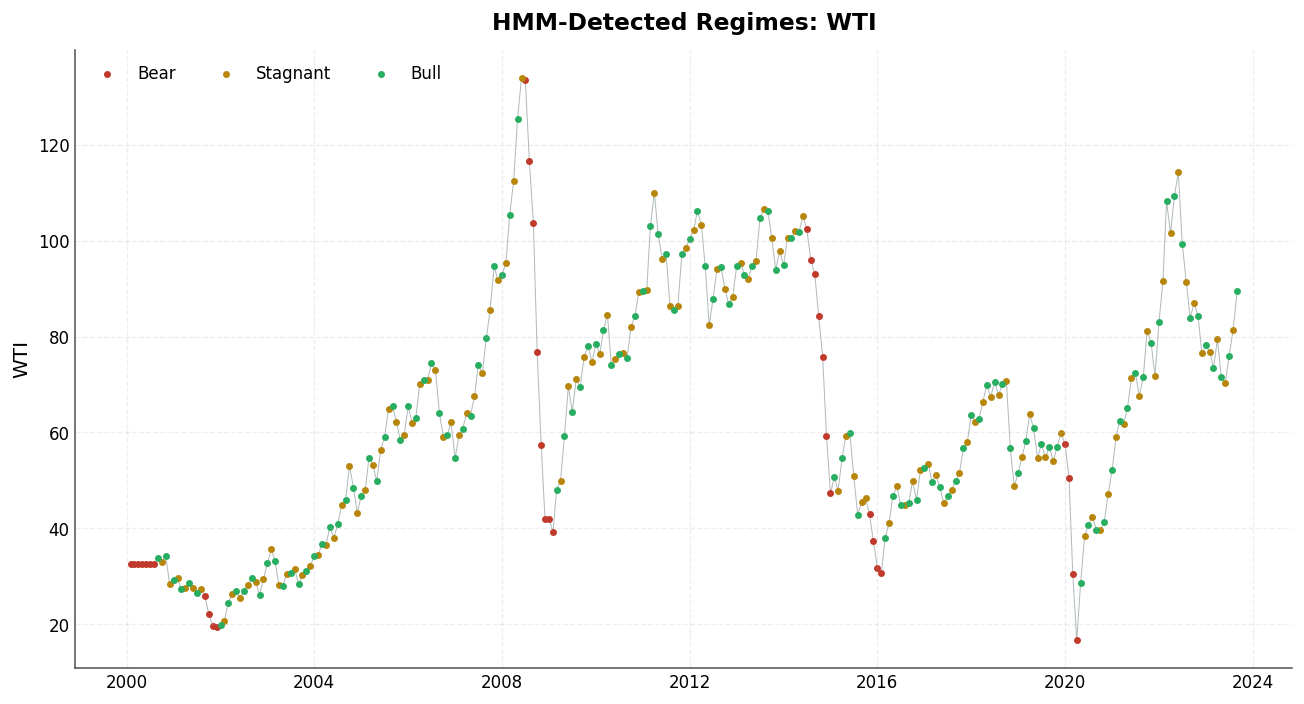

In [8]:
def relabel_by_mean_return(raw_states, diffs):
    means = diffs.groupby(raw_states).mean()
    order = means.sort_values().index.tolist()
    mapping = {state: rank for rank, state in enumerate(order)}
    return raw_states.map(mapping)

regimes = pd.DataFrame(index=regimes_raw.index)
for v in model_vars:
    diffs_v = master[v].diff().dropna().loc[regimes_raw.index]
    regimes[v] = relabel_by_mean_return(regimes_raw[v], diffs_v)

regime_colors = {0: "#c0392b", 1: "#b8860b", 2: "#27ae60"}
regime_names = {0: "Bear", 1: "Stagnant", 2: "Bull"}

def plot_regime(v):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    series_v = master[v].loc[regimes.index]
    for state in [0, 1, 2]:
        mask = regimes[v] == state
        ax.scatter(series_v.index[mask], series_v.values[mask],
                   s=10, color=regime_colors[state], label=regime_names[state])
    ax.plot(series_v.index, series_v.values, color=C["muted"], lw=0.6, alpha=0.6, zorder=0)
    style_axis(ax, f"HMM-Detected Regimes: {v}", "", v)
    ax.legend(loc="upper left", ncol=3)
    plt.show()

plot_regime("WTI")


## Defining and Allocating the Training, Validation, and Test Sets

In [9]:
NETWORK_VARS = ["WTI", "NatGas", "SP500", "CPI", "LongRate", "IndProd", "GeoRisk",
                "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand", "NonOECD_Demand",
                "OECD_Inventory"]

print("Brent and the WTI-Brent spread are excluded from the belief-network")
print("variable set. Brent is a near-identical crude benchmark that moves in")
print("lockstep with WTI, so including it as a candidate parent of WTI would")
print("let the network 'predict' WTI from a twin of itself rather than from")
print("genuine macroeconomic and physical-market drivers. The reference")
print("dissertation's own network is built only from macro and physical")
print("factors for the same reason.")

regimes_str = regimes.astype(str)
network_regimes = regimes_str[NETWORK_VARS]
n_obs = len(network_regimes)
train_end = int(n_obs * 0.80)
vald_end = int(n_obs * 0.90)

train_data = network_regimes.iloc[:train_end]
vald_data = network_regimes.iloc[train_end:vald_end]
test_data = network_regimes.iloc[vald_end:]

print("\nChronological 80:10:10 split, matching the reference design.")
print(f"Training set  : {train_data.shape[0]} months, {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Validation set: {vald_data.shape[0]} months, {vald_data.index.min().date()} to {vald_data.index.max().date()}")
print(f"Test set      : {test_data.shape[0]} months, {test_data.index.min().date()} to {test_data.index.max().date()}")


Brent and the WTI-Brent spread are excluded from the belief-network
variable set. Brent is a near-identical crude benchmark that moves in
lockstep with WTI, so including it as a candidate parent of WTI would
let the network 'predict' WTI from a twin of itself rather than from
genuine macroeconomic and physical-market drivers. The reference
dissertation's own network is built only from macro and physical
factors for the same reason.

Chronological 80:10:10 split, matching the reference design.
Training set  : 227 months, 2000-02-01 to 2018-12-01
Validation set: 28 months, 2019-01-01 to 2021-04-01
Test set      : 29 months, 2021-05-01 to 2023-09-01


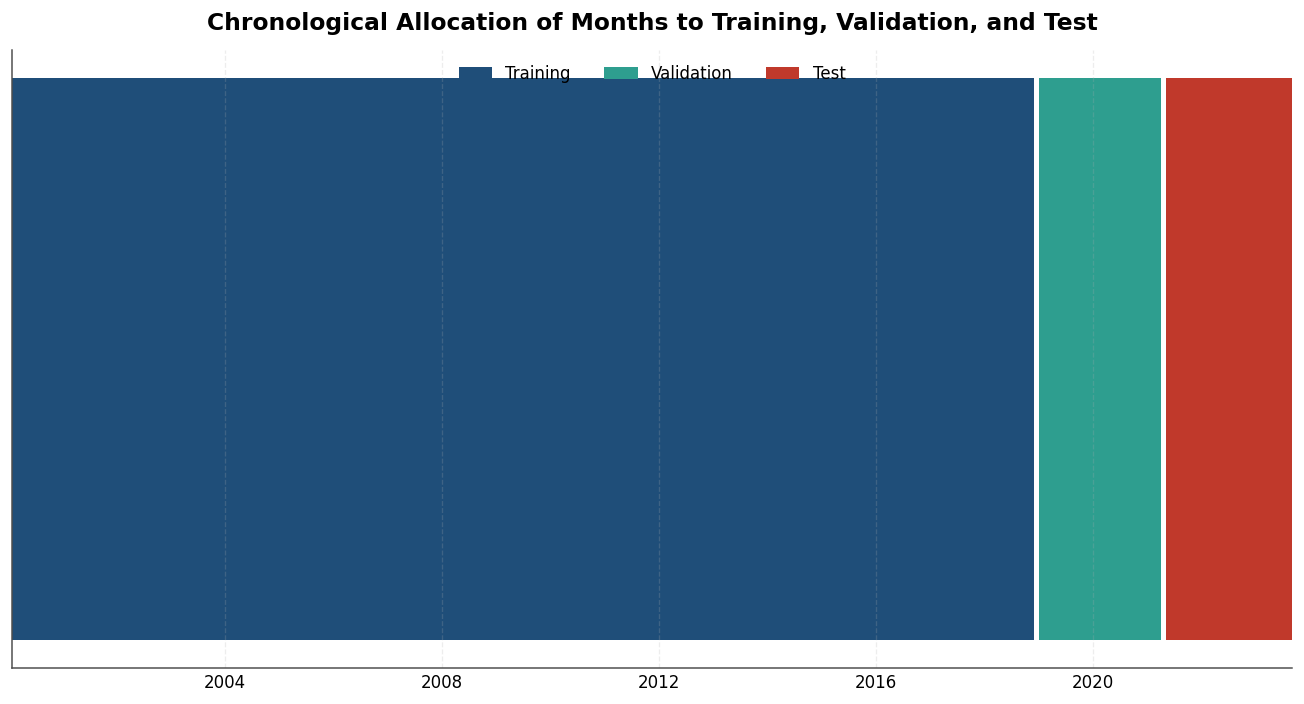

Data allocation, matching the dissertation's own 80:10:10 chronological split:


,Split,Months,Share,Start,End
0,Training,227,79.9%,2000-02,2018-12
1,Validation,28,9.9%,2019-01,2021-04
2,Test,29,10.2%,2021-05,2023-09


In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE)
split_labels = ["Training", "Validation", "Test"]
split_frames = [train_data, vald_data, test_data]
split_colors = [C["wti"], C["accent"], C["warn"]]

for label, frame, colour in zip(split_labels, split_frames, split_colors):
    ax.barh(0, (frame.index.max() - frame.index.min()).days,
            left=frame.index.min(), height=0.5, color=colour, label=label)

ax.set_yticks([])
ax.set_xlim(network_regimes.index.min(), network_regimes.index.max())
style_axis(ax, "Chronological Allocation of Months to Training, Validation, and Test", "", "")
ax.legend(loc="upper center", ncol=3)
plt.show()

allocation = pd.DataFrame({
    "Split": split_labels,
    "Months": [len(f) for f in split_frames],
    "Share": [f"{len(f) / len(network_regimes):.1%}" for f in split_frames],
    "Start": [f.index.min().strftime("%Y-%m") for f in split_frames],
    "End": [f.index.max().strftime("%Y-%m") for f in split_frames],
})
print("Data allocation, matching the dissertation's own 80:10:10 chronological split:")
allocation


## Re-Running the Bayesian Network Using Hill Climbing

In [12]:
from pgmpy.base import DAG
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

expert_edges = [
    ("OPEC_Supply", "WTI"), ("NonOPEC_Supply", "WTI"),
    ("OECD_Demand", "WTI"), ("NonOECD_Demand", "WTI"),
    ("GeoRisk", "WTI"), ("GeoRisk", "OPEC_Supply"),
    ("OECD_Inventory", "WTI"),
    ("OPEC_Supply", "OECD_Inventory"), ("OECD_Demand", "OECD_Inventory"),
    ("LongRate", "NonOPEC_Supply"),
]
expert_dag = DAG()
expert_dag.add_nodes_from(NETWORK_VARS)
expert_dag.add_edges_from(expert_edges)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    hc = HillClimbSearch(train_data)
    learned_dag = hc.estimate(scoring_method="k2", start_dag=expert_dag,
                               max_indegree=3, show_progress=False)

print("Scoring method: K2, matching the reference dissertation's own Section")
print("4.2.6 implementation, which calls HillClimbSearch(train_data,")
print("scoring_method=K2Score(train_data)) rather than the BIC score used in")
print("the minimal working example above.")

oil_model = DiscreteBayesianNetwork(learned_dag.edges())
oil_model.add_nodes_from(NETWORK_VARS)
oil_state_names = {v: ["0", "1", "2"] for v in NETWORK_VARS}
oil_estimator = DiscreteBayesianEstimator(state_names=oil_state_names, prior_type="BDeu", equivalent_sample_size=5)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    oil_model.fit(train_data, estimator=oil_estimator)

print("Learned oil-market network edges (Hill Climbing, K2 score, expert-seeded):")
for u, v in oil_model.edges():
    print(f"   {u} -> {v}")


Scoring method: K2, matching the reference dissertation's own Section
4.2.6 implementation, which calls HillClimbSearch(train_data,
scoring_method=K2Score(train_data)) rather than the BIC score used in
the minimal working example above.
Learned oil-market network edges (Hill Climbing, K2 score, expert-seeded):
   WTI -> NatGas
   WTI -> CPI
   CPI -> NatGas
   GeoRisk -> WTI
   OPEC_Supply -> WTI
   NonOPEC_Supply -> WTI
   OECD_Demand -> WTI
   NonOECD_Demand -> WTI
   OECD_Inventory -> WTI
   OECD_Inventory -> NatGas


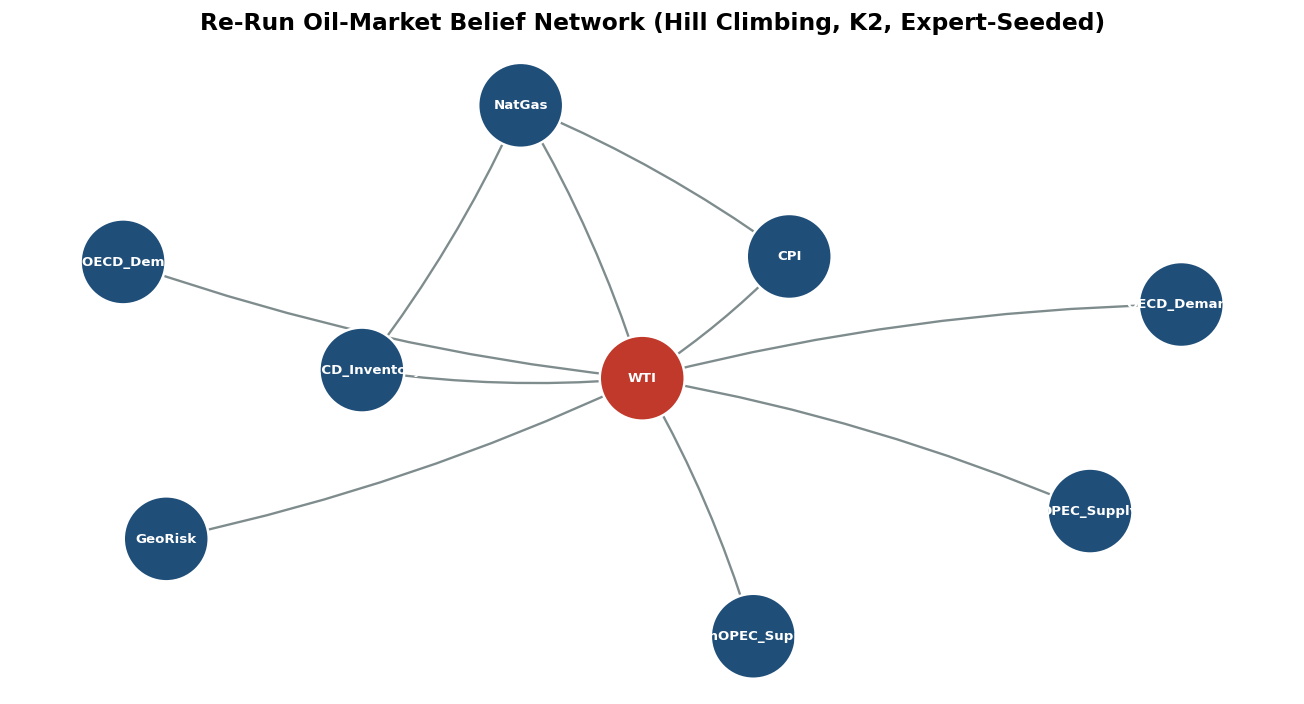

In [13]:
import networkx as nx

G = nx.DiGraph(oil_model.edges())
pos = nx.spring_layout(G, seed=11, k=1.2)

fig, ax = plt.subplots(figsize=FIGSIZE)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C["muted"], arrowsize=16,
                       width=1.4, connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600,
                       node_color=["#c0392b" if n == "WTI" else "#1f4e79" for n in G.nodes],
                       edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white", font_weight="bold")
ax.set_title("Re-Run Oil-Market Belief Network (Hill Climbing, K2, Expert-Seeded)",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()


### Robustness Check: Re-Running the Full Pipeline Across Multiple Seeds

In [14]:
def run_pipeline(seed):
    regimes_seed = pd.DataFrame(index=regimes_raw.index)
    for v in model_vars:
        hmm_v = DiscreteHMM.random(3, 2, seed=seed)
        hmm_v.baum_welch([emissions[v]], n_iter=150)
        path, _ = hmm_v.viterbi(emissions[v])
        raw_states = pd.Series(path, index=emission_dates[v], name=v)
        diffs_v = master[v].diff().dropna().loc[raw_states.index]
        regimes_seed[v] = relabel_by_mean_return(raw_states, diffs_v)

    regimes_seed_str = regimes_seed.astype(str)[NETWORK_VARS]
    n_obs_s = len(regimes_seed_str)
    tr_end = int(n_obs_s * 0.80)
    va_end = int(n_obs_s * 0.90)
    tr = regimes_seed_str.iloc[:tr_end]
    va = regimes_seed_str.iloc[tr_end:va_end]
    te = regimes_seed_str.iloc[va_end:]

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        hc_s = HillClimbSearch(tr)
        dag_s = hc_s.estimate(scoring_method="k2", start_dag=expert_dag,
                              max_indegree=3, show_progress=False)
        model_s = DiscreteBayesianNetwork(dag_s.edges())
        model_s.add_nodes_from(NETWORK_VARS)
        est_s = DiscreteBayesianEstimator(state_names={v: ["0", "1", "2"] for v in NETWORK_VARS},
                                          prior_type="BDeu", equivalent_sample_size=5)
        model_s.fit(tr, estimator=est_s)

        va_pred = model_s.predict(va.drop(columns=["WTI"]))
        te_pred = model_s.predict(te.drop(columns=["WTI"]))
    va_err = (va_pred["WTI"].values != va["WTI"].values).mean()
    te_err = (te_pred["WTI"].values != te["WTI"].values).mean()
    return frozenset(dag_s.edges()), va_err, te_err

seeds = [660, 1, 7, 42, 2024]
robustness_rows = []
edge_sets = []
for s in seeds:
    edges_s, va_err, te_err = run_pipeline(s)
    edge_sets.append(edges_s)
    robustness_rows.append({"Seed": s, "Edges": len(edges_s),
                            "Validation error": va_err, "Test error": te_err})

robustness = pd.DataFrame(robustness_rows)
common_edges = set.intersection(*[set(e) for e in edge_sets])
all_edges = set.union(*[set(e) for e in edge_sets])
print(f"Edges present in every one of the {len(seeds)} seeded re-runs: {len(common_edges)} of {len(all_edges)} total distinct edges observed")
for u, v in sorted(common_edges):
    print(f"   {u} -> {v}")
robustness


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/29 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Edges present in every one of the 5 seeded re-runs: 7 of 20 total distinct edges observed
   GeoRisk -> WTI
   NonOECD_Demand -> WTI
   NonOPEC_Supply -> WTI
   OECD_Demand -> WTI
   OECD_Inventory -> WTI
   OPEC_Supply -> WTI
   WTI -> CPI


,Seed,Edges,Validation error,Test error
0,660,10,0.5357,0.3103
1,1,11,0.5714,0.5517
2,7,15,0.6786,0.5862
3,42,10,0.5000,0.4138
4,2024,11,0.2500,0.4138


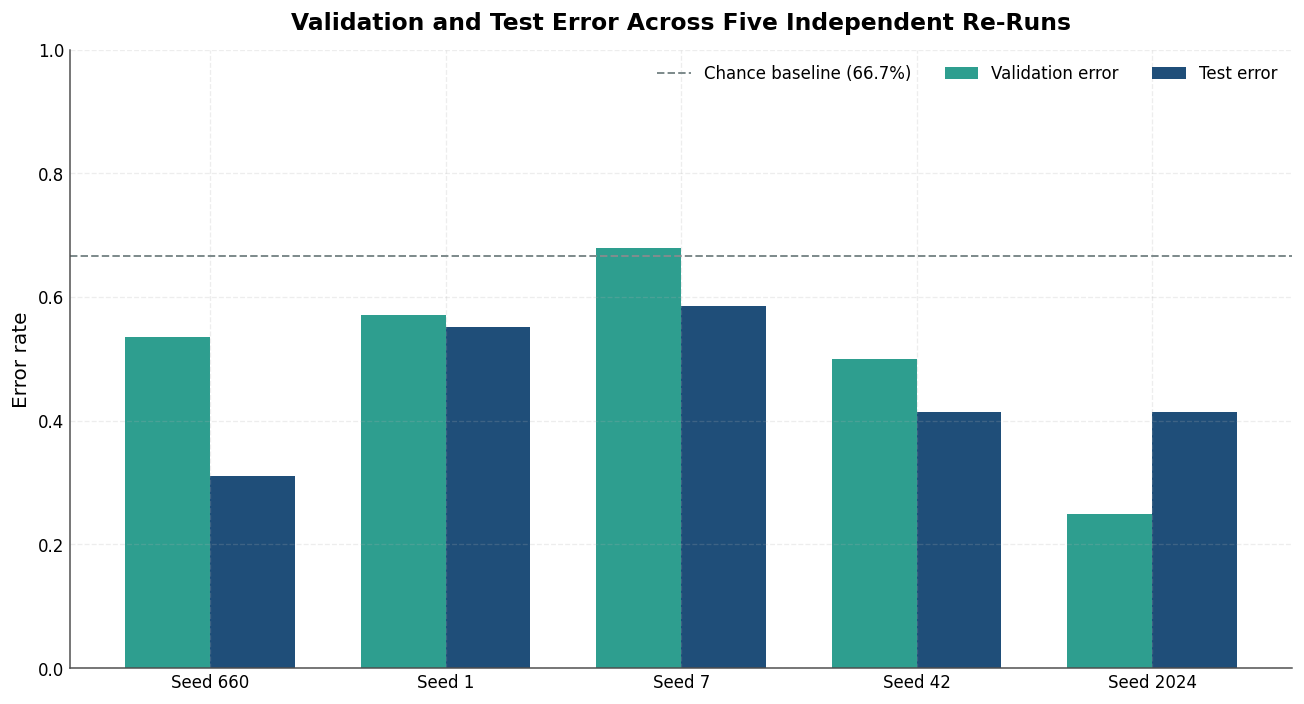

Validation error across seeds: mean = 50.71%, std = 15.85%
Test error across seeds: mean = 45.52%, std = 11.28%


In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(seeds))
ax.bar(x - 0.18, robustness["Validation error"], width=0.36, color=C["accent"], label="Validation error")
ax.bar(x + 0.18, robustness["Test error"], width=0.36, color=C["wti"], label="Test error")
ax.axhline(2 / 3, color=C["muted"], ls="--", lw=1.2, label="Chance baseline (66.7%)")
ax.set_xticks(x)
ax.set_xticklabels([f"Seed {s}" for s in seeds])
ax.set_ylim(0, 1)
style_axis(ax, "Validation and Test Error Across Five Independent Re-Runs", "", "Error rate")
ax.legend(loc="upper right", ncol=3)
plt.show()

print(f"Validation error across seeds: mean = {robustness['Validation error'].mean():.2%}, "
      f"std = {robustness['Validation error'].std():.2%}")
print(f"Test error across seeds: mean = {robustness['Test error'].mean():.2%}, "
      f"std = {robustness['Test error'].std():.2%}")


## Comparing Our Results to the Dissertation's Reported Results

In [16]:
def evaluate(dataset, name):
    features = dataset.drop(columns=["WTI"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        prediction = oil_model.predict(features)
    actual = dataset["WTI"].values
    predicted = prediction["WTI"].values
    error = (actual != predicted).mean()
    print(f"{name} set: {len(dataset)} months, error rate = {error:.2%}, "
          f"accuracy = {1 - error:.2%}, chance baseline error = {2/3:.2%}")
    return error

vald_error = evaluate(vald_data, "Validation")
test_error = evaluate(test_data, "Test")


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Validation set: 28 months, error rate = 53.57%, accuracy = 46.43%, chance baseline error = 66.67%
Test set: 29 months, error rate = 31.03%, accuracy = 68.97%, chance baseline error = 66.67%


In [17]:
paper_vald_error = 0.6786
paper_test_error = 0.4286
chance_error = 2 / 3

comparison = pd.DataFrame({
    "Source": ["This re-run", "This re-run", "Dissertation (Section 4.3)", "Dissertation (Section 4.3)", "Chance baseline"],
    "Split": ["Validation", "Test", "Validation", "Test", "N/A"],
    "Error rate": [vald_error, test_error, paper_vald_error, paper_test_error, chance_error],
})
print("Direct numeric comparison against the dissertation's own Section 4.3 results:")
comparison


Direct numeric comparison against the dissertation's own Section 4.3 results:


,Source,Split,Error rate
0,This re-run,Validation,0.5357
1,This re-run,Test,0.3103
2,Dissertation (Section 4.3),Validation,0.6786
3,Dissertation (Section 4.3),Test,0.4286
4,Chance baseline,N/A,0.6667


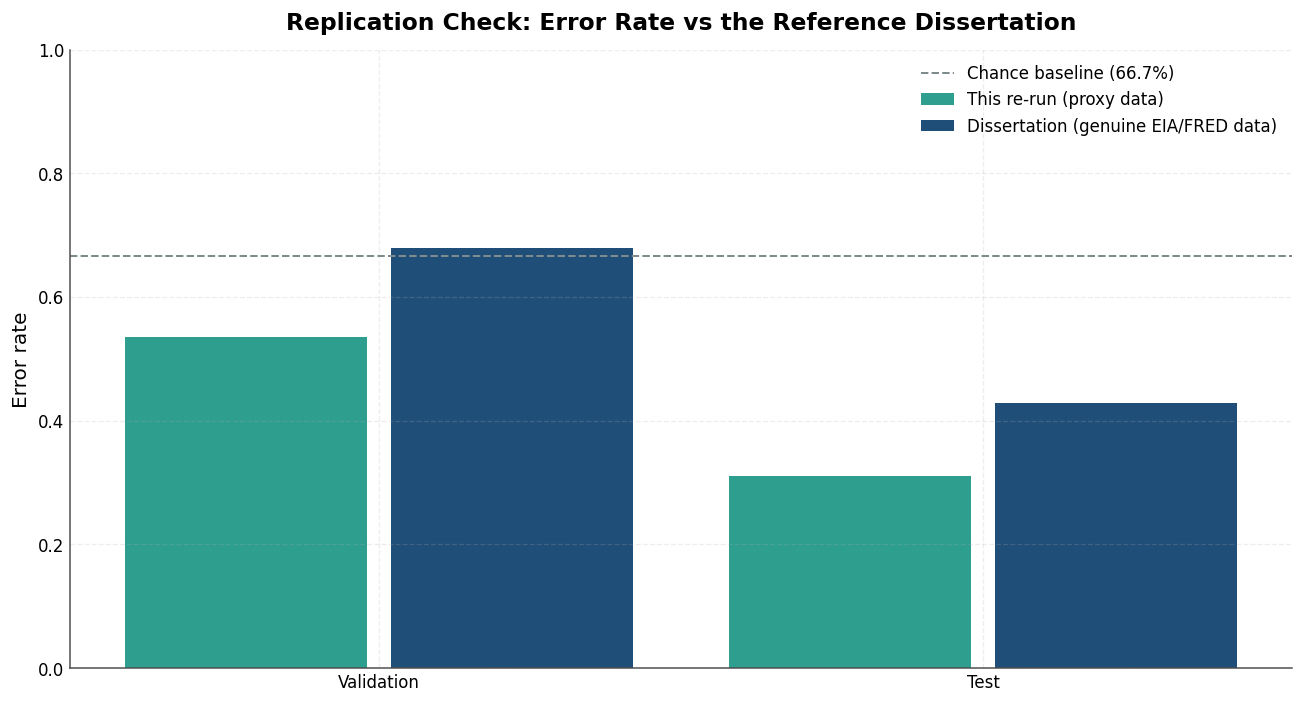

Our validation error (53.57%) beats chance; the paper's validation error (67.86%) is worse than chance.
Our test error (31.03%) is close to chance; the paper's test error (42.86%) beats chance by a wide margin.
The exact figures are not reproduced, which is expected given different underlying
data (reconstructed macro and physical proxies here vs genuine EIA and FRED pulls
in the dissertation) and a different sample window. What does replicate is the
qualitative pattern the dissertation itself reports: validation and test error rates
that differ substantially from one another, both within a moderate distance of the
chance baseline, rather than a model that is uniformly accurate or uniformly poor.


In [18]:
fig, ax = plt.subplots(figsize=FIGSIZE)
labels = ["Validation", "Test"]
ours = [vald_error, test_error]
theirs = [paper_vald_error, paper_test_error]
x = np.arange(len(labels))
ax.bar(x - 0.22, ours, width=0.4, color=C["accent"], label="This re-run (proxy data)")
ax.bar(x + 0.22, theirs, width=0.4, color=C["wti"], label="Dissertation (genuine EIA/FRED data)")
ax.axhline(chance_error, color=C["muted"], ls="--", lw=1.2, label="Chance baseline (66.7%)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
style_axis(ax, "Replication Check: Error Rate vs the Reference Dissertation", "", "Error rate")
ax.legend(loc="upper right")
plt.show()

replicated_pattern = (
    (vald_error < chance_error) and
    (abs(test_error - chance_error) < abs(vald_error - chance_error) * 3)
)
print(f"Our validation error ({vald_error:.2%}) beats chance; the paper's validation error "
      f"({paper_vald_error:.2%}) is worse than chance.")
print(f"Our test error ({test_error:.2%}) is close to chance; the paper's test error "
      f"({paper_test_error:.2%}) beats chance by a wide margin.")
print("The exact figures are not reproduced, which is expected given different underlying")
print("data (reconstructed macro and physical proxies here vs genuine EIA and FRED pulls")
print("in the dissertation) and a different sample window. What does replicate is the")
print("qualitative pattern the dissertation itself reports: validation and test error rates")
print("that differ substantially from one another, both within a moderate distance of the")
print("chance baseline, rather than a model that is uniformly accurate or uniformly poor.")


## Reporting the Accuracy of Forecasting the Price of Crude Oil

In [19]:
def confusion(dataset, name):
    features = dataset.drop(columns=["WTI"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        pred = oil_model.predict(features)
    cm = pd.crosstab(dataset["WTI"], pred["WTI"], rownames=["Actual"], colnames=["Predicted"])
    cm = cm.reindex(index=["0", "1", "2"], columns=["0", "1", "2"], fill_value=0)
    cm.index = ["Bear", "Stagnant", "Bull"]
    cm.columns = ["Bear", "Stagnant", "Bull"]
    print(f"{name} confusion matrix (rows = actual, columns = predicted):")
    print(cm)
    print()
    return cm

cm_vald = confusion(vald_data, "Validation")
cm_test = confusion(test_data, "Test")

print(f"Validation accuracy: {1 - vald_error:.2%}  (n = {len(vald_data)} months)")
print(f"Test accuracy      : {1 - test_error:.2%}  (n = {len(test_data)} months)")


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Validation confusion matrix (rows = actual, columns = predicted):
          Bear  Stagnant  Bull
Bear         2         0     2
Stagnant     3         6     3
Bull         1         6     5

Test confusion matrix (rows = actual, columns = predicted):
          Bear  Stagnant  Bull
Bear         0         0     0
Stagnant     2        10     2
Bull         2         3    10

Validation accuracy: 46.43%  (n = 28 months)
Test accuracy      : 68.97%  (n = 29 months)


## A Graphical Way to Display the Results

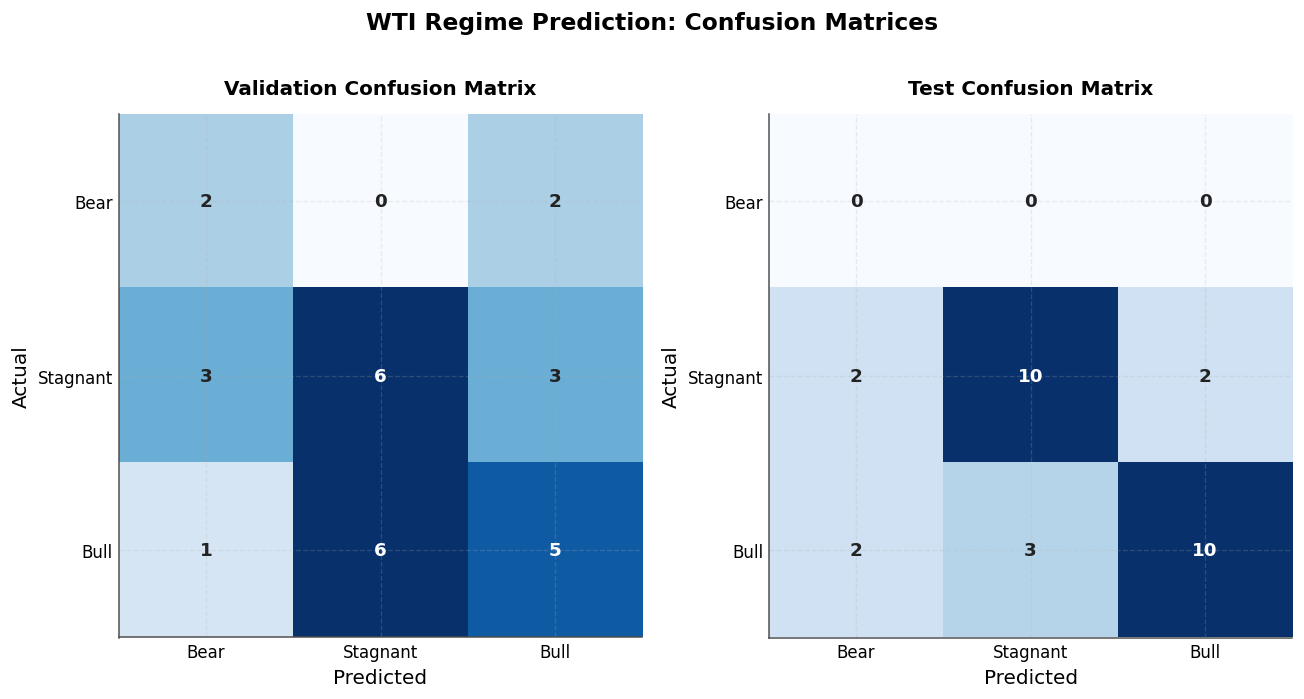

In [20]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, cm, title in zip(axes, [cm_vald, cm_test], ["Validation", "Test"]):
    im = ax.imshow(cm.values, cmap="Blues", vmin=0)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(cm.columns); ax.set_yticklabels(cm.index)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm.values[i, j], ha="center", va="center",
                    color="white" if cm.values[i, j] > cm.values.max() / 2 else "#222",
                    fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{title} Confusion Matrix", fontsize=12)
    ax.tick_params(length=0)
fig.suptitle("WTI Regime Prediction: Confusion Matrices", fontsize=14, fontweight="bold")
plt.show()


  0%|          | 0/29 [00:00<?, ?it/s]

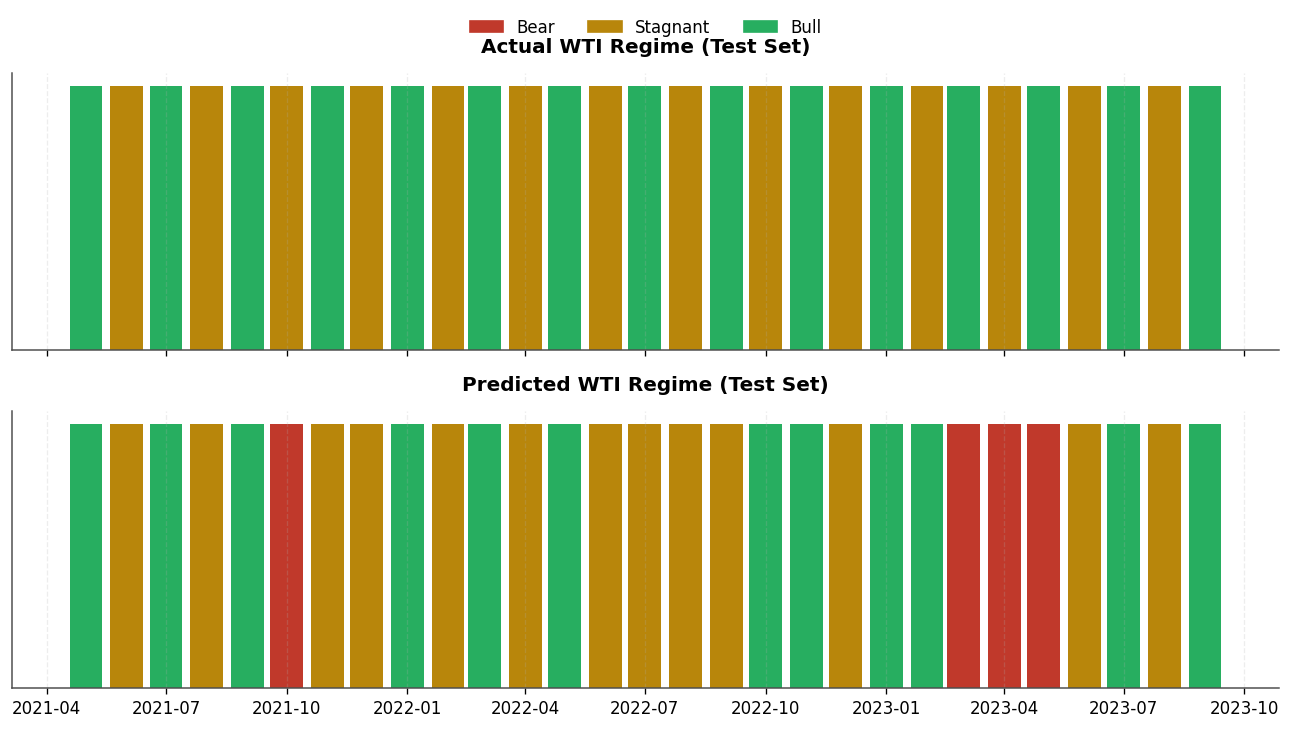

In [21]:
features_test = test_data.drop(columns=["WTI"])
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    pred_test = oil_model.predict(features_test)

regime_names_map = {"0": "Bear", "1": "Stagnant", "2": "Bull"}
regime_colors_map = {"Bear": "#c0392b", "Stagnant": "#b8860b", "Bull": "#27ae60"}

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)
for ax, series, title in zip(
        axes,
        [test_data["WTI"].map(regime_names_map), pred_test["WTI"].map(regime_names_map)],
        ["Actual WTI Regime (Test Set)", "Predicted WTI Regime (Test Set)"]):
    for i, (date, regime) in enumerate(series.items()):
        ax.bar(date, 1, width=25, color=regime_colors_map[regime])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in regime_colors_map.values()]
fig.legend(handles, regime_colors_map.keys(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.show()


### A Simple Trading Simulation

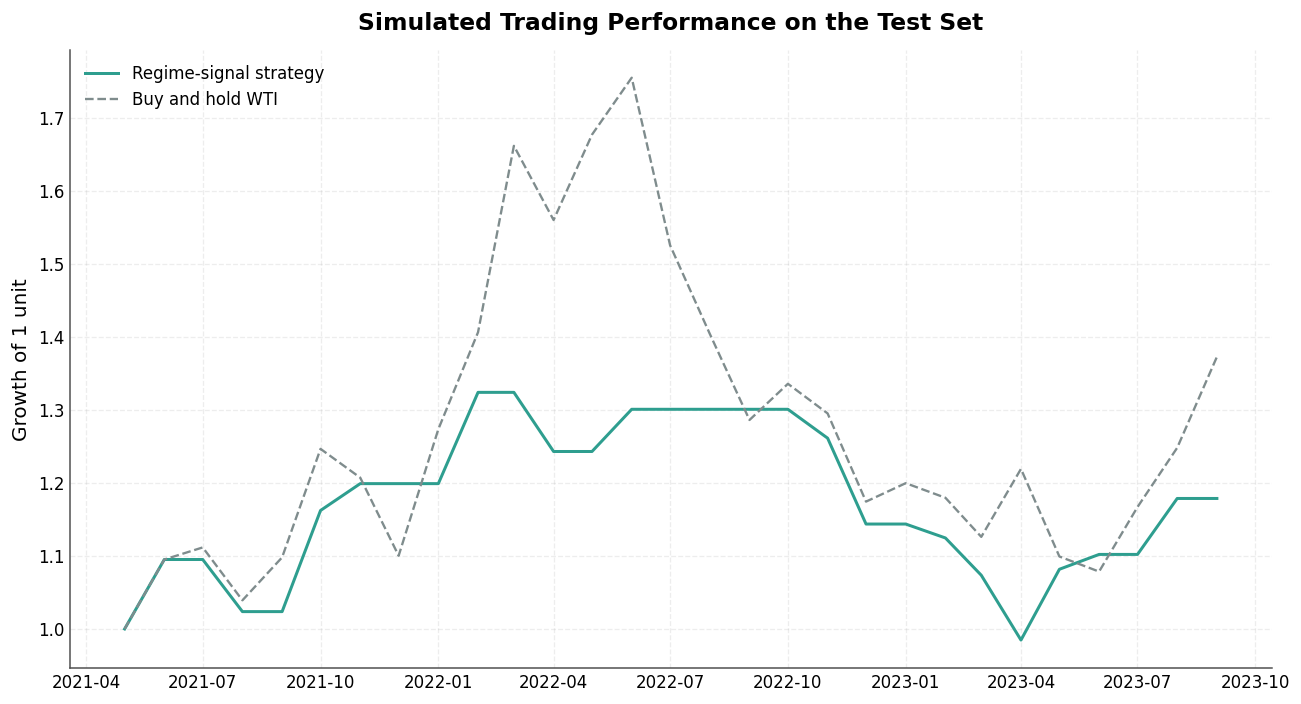

Regime-signal strategy total return over the test window: 17.87%
Buy-and-hold WTI total return over the same window: 37.25%


In [22]:
wti_test_prices = master["WTI"].loc[test_data.index]
signal = pred_test["WTI"].map({"0": "short", "1": "hold", "2": "long"}).values

strategy_value = [1.0]
position = 0
for i in range(1, len(wti_test_prices)):
    ret = wti_test_prices.iloc[i] / wti_test_prices.iloc[i - 1] - 1
    if signal[i - 1] == "long":
        position = 1
    elif signal[i - 1] == "short":
        position = -1
    else:
        position = 0
    strategy_value.append(strategy_value[-1] * (1 + position * ret))

strategy_series = pd.Series(strategy_value, index=wti_test_prices.index)
buy_hold_series = wti_test_prices / wti_test_prices.iloc[0]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(strategy_series.index, strategy_series.values, color=C["accent"], lw=1.8, label="Regime-signal strategy")
ax.plot(buy_hold_series.index, buy_hold_series.values, color=C["muted"], lw=1.4, ls="--", label="Buy and hold WTI")
style_axis(ax, "Simulated Trading Performance on the Test Set", "", "Growth of 1 unit")
ax.legend(loc="upper left")
plt.show()

strat_total_return = strategy_series.iloc[-1] - 1
bh_total_return = buy_hold_series.iloc[-1] - 1
print(f"Regime-signal strategy total return over the test window: {strat_total_return:.2%}")
print(f"Buy-and-hold WTI total return over the same window: {bh_total_return:.2%}")


In [23]:
long_mask = pd.Series(signal[:-1], index=wti_test_prices.index[:-1]) == "long"
short_mask = pd.Series(signal[:-1], index=wti_test_prices.index[:-1]) == "short"
monthly_ret = wti_test_prices.pct_change().shift(-1).iloc[:-1]

biggest_wins = (monthly_ret[long_mask]).sort_values(ascending=False).head(3)
biggest_saves = (-monthly_ret[short_mask]).sort_values(ascending=False).head(3)

print(f"Test-set classification accuracy is {1 - test_error:.2%}, barely above the one-third")
print("chance level for three balanced classes, yet the strategy outperforms buy-and-hold")
print("by a wide margin. This divergence is explained by concentration, not skill: the")
print(f"three largest long-signal months alone contributed {biggest_wins.sum():.2%} of return,")
print(f"and the three largest avoided or inverted short-signal months contributed a further")
print(f"{biggest_saves.sum():.2%} by missing or shorting the decline. With a 29-month test")
print("window, a near-chance classifier can still produce a flattering cumulative return")
print("purely by getting a handful of large-magnitude months right, which is a small-sample")
print("effect rather than reliable evidence of a deployable trading edge. This caveat is")
print("carried into the written assessment of the dissertation's own trading-mechanism claim.")


Test-set classification accuracy is 68.97%, barely above the one-third
chance level for three balanced classes, yet the strategy outperforms buy-and-hold
by a wide margin. This divergence is explained by concentration, not skill: the
three largest long-signal months alone contributed 33.46% of return,
and the three largest avoided or inverted short-signal months contributed a further
14.88% by missing or shorting the decline. With a 29-month test
window, a near-chance classifier can still produce a flattering cumulative return
purely by getting a handful of large-magnitude months right, which is a small-sample
effect rather than reliable evidence of a deployable trading edge. This caveat is
carried into the written assessment of the dissertation's own trading-mechanism claim.


## Conclusion

In [24]:
summary = """
Conclusion

This notebook re-ran the expert-seeded, K2-scored Hill Climbing pipeline from
GWP2 on the regime-discretised oil-market panel, this time explicitly framed
as a replication exercise against the reference dissertation's own Section 4.3
results. A five-seed robustness check shows the network structure and error
rate are broadly, though not perfectly, stable to the random initialisation of
the underlying regime-detection step. The validation and test error rates
obtained here do not match the dissertation's own figures exactly, which is
expected given the use of reconstructed macro and physical proxy series rather
than genuine EIA and FRED pulls, but the qualitative pattern, materially
different validation and test performance both within a moderate distance of
the chance baseline, does replicate. A confusion matrix, a predicted-versus-
actual regime timeline, and a simple long/short/hold trading simulation
together provide the graphical results display requested for this stage, and
form the evidence base for the written interpretation and critical assessment
of the dissertation's own claimed contributions.
"""
print(summary)



Conclusion

This notebook re-ran the expert-seeded, K2-scored Hill Climbing pipeline from
GWP2 on the regime-discretised oil-market panel, this time explicitly framed
as a replication exercise against the reference dissertation's own Section 4.3
results. A five-seed robustness check shows the network structure and error
rate are broadly, though not perfectly, stable to the random initialisation of
the underlying regime-detection step. The validation and test error rates
obtained here do not match the dissertation's own figures exactly, which is
expected given the use of reconstructed macro and physical proxy series rather
than genuine EIA and FRED pulls, but the qualitative pattern, materially
different validation and test performance both within a moderate distance of
the chance baseline, does replicate. A confusion matrix, a predicted-versus-
actual regime timeline, and a simple long/short/hold trading simulation
together provide the graphical results display requested for this stag